# Rough Volatility H Estimation

This notebook adapts section 2 of *Volatility is rough* by Gatheral, Jaisson, and Rosenbaum (2018) to Binance `BTCUSDC` replay data.

Analysis source:
- paper: `Volatility is rough`
- section: 2, especially section 2.1 (`Estimating the smoothness of the volatility process`)
- local adaptation: one-minute BTCUSDC mid-price returns and a trailing 15-minute realized-volatility proxy

What this notebook does:
- define a causal volatility proxy from the top-of-book mid price
- estimate the roughness exponent `H` from log-volatility scaling
- recompute `H` every minute on a rolling calibration window
- inspect whether `H` stays stable through the sample

Data provenance:
- Binance recorder data is resolved through the local replay / cache pipeline
- the notebook does not re-parse raw recorder files in cells
- day boundaries are respected; overnight gaps are not bridged


## Definitions

Let `m_t` be the mid price at time `t`:

$$m_t = \frac{b_t + a_t}{2}$$

On a one-minute grid, define the log return

$$r_t = \log(m_t) - \log(m_{t-1}).$$

A causal trailing realized-volatility proxy over a `15m` window is

$$\mathrm{RV}_t = \sqrt{\sum_{u \in (t-15m,\,t)} r_u^2}.$$ 

The log-volatility proxy is

$$x_t = \log(\mathrm{RV}_t).$$

For the roughness estimate we study the moments

$$m_q(\Delta) = \mathbb{E}[|x_{t+\Delta} - x_t|^q].$$

Section 2 of the paper uses the empirical scaling relation

$$\log m_q(\Delta) \approx a_q + \zeta_q \log \Delta,$$

followed by a second linear fit

$$\zeta_q \approx H q.$$

This notebook follows that logic with a Binance-specific proxy: `H` is estimated from the scaling of `log(RV)` rather than from an unobserved spot volatility process.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import importlib.util

def load_notebook_utils(start: Path | None = None):
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        utils_path = candidate / "notebooks" / "notebook_utils.py"
        if utils_path.is_file():
            spec = importlib.util.spec_from_file_location("notebook_utils", utils_path)
            if spec is None or spec.loader is None:
                raise ImportError(f"Could not load notebook utilities from {utils_path}")
            module = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(module)
            return module
    raise FileNotFoundError("Could not locate notebooks/notebook_utils.py")


notebook_utils = load_notebook_utils()
PROJECT_ROOT = notebook_utils.bootstrap_backtester_path()

from stats.notebook import load_orderflow_day

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)
plt.style.use("seaborn-v0_8-whitegrid")


In [2]:
symbol = "BTCUSDC"
exchange = "binance"

# Default sample range. Adjust this list if you want a different study window.
days = ["20260226", "20260227", "20260228"]

# Baseline proxy setup: one-minute returns, trailing 15-minute realized volatility.
grid_freq = "1min"
rv_window = "15min"

# Rolling roughness estimation window.
# This is intentionally much longer than the proxy window.
calibration_window = "6h"

# Scaling fit parameters.
lag_minutes = list(range(1, 31))
q_grid = np.array([0.5, 1.0, 1.5, 2.0, 3.0], dtype=float)


In [3]:
def build_minute_mid_series(top: pd.DataFrame, *, grid_freq: str = "1min") -> pd.Series:
    """Return a causal one-minute mid-price series from the cached top-of-book table."""
    frame = top[["ts", "mid"]].dropna().copy()
    if frame.empty:
        return pd.Series(dtype="float64", index=pd.DatetimeIndex([], tz="UTC", name="ts"))

    frame["ts"] = pd.to_datetime(frame["ts"], utc=True)
    minute_mid = frame.sort_values("ts").set_index("ts")["mid"].resample(grid_freq).last().ffill()
    minute_mid.name = "mid"
    return minute_mid.dropna()


def build_roughness_proxy(minute_mid: pd.Series, *, rv_window: str = "15min", min_periods: int = 15) -> pd.DataFrame:
    """Compute the mid, log-mid, one-minute return, realized-vol proxy, and log-vol proxy."""
    out = minute_mid.to_frame().copy()
    out["log_mid"] = np.log(out["mid"].astype(float))
    out["log_mid_ret"] = out["log_mid"].diff()
    out["rv"] = (
        out["log_mid_ret"].pow(2)
        .rolling(rv_window, closed="left", min_periods=min_periods)
        .sum()
        .pow(0.5)
    )
    out["log_rv"] = np.log(out["rv"].clip(lower=1e-12))
    return out


daily = {}
summary_rows = []

for day in days:
    dataset, trades, top, summary = load_orderflow_day(
        day=day,
        symbol=symbol,
        exchange=exchange,
        replay_on_gap="skip-segment",
    )
    minute_mid = build_minute_mid_series(top, grid_freq=grid_freq)
    proxy = build_roughness_proxy(minute_mid, rv_window=rv_window)

    daily[day] = {
        "dataset": dataset,
        "summary": summary,
        "top": top,
        "minute_mid": minute_mid,
        "proxy": proxy,
    }

    summary_rows.append(
        {
            "day": day,
            "day_dir": str(dataset.day_dir),
            "top_rows": int(len(top)),
            "minute_rows": int(len(minute_mid)),
            "proxy_rows": int(proxy["log_rv"].notna().sum()),
            "rv_nonnull_share": float(proxy["rv"].notna().mean()),
            "trade_start_utc": summary["trade_start_utc"],
            "trade_end_utc": summary["trade_end_utc"],
            "top_start_utc": summary["top_start_utc"],
            "top_end_utc": summary["top_end_utc"],
        }
    )

data_summary = pd.DataFrame(summary_rows).set_index("day")
data_summary


,day_dir,top_rows,minute_rows,proxy_rows,rv_nonnull_share,trade_start_utc,trade_end_utc,top_start_utc,top_end_utc
day,,,,,,,,,
20260226,/Users/hoangdeveloper/PycharmProjects/exchange...,724678,1336,1320,0.988024,2026-02-26 01:00:10.687000+00:00,2026-02-26 23:14:58.616000+00:00,2026-02-26 01:00:10.267000+00:00,2026-02-26 23:15:00.035000+00:00
20260227,/Users/hoangdeveloper/PycharmProjects/exchange...,731484,1336,1320,0.988024,2026-02-27 01:00:16.289000+00:00,2026-02-27 23:14:58.124000+00:00,2026-02-27 01:00:13.978000+00:00,2026-02-27 23:15:00.035000+00:00
20260228,/Users/hoangdeveloper/PycharmProjects/exchange...,719409,1336,1320,0.988024,2026-02-28 01:00:12.847000+00:00,2026-02-28 23:14:59.026000+00:00,2026-02-28 01:00:12.829000+00:00,2026-02-28 23:15:00.034000+00:00


## Baseline Proxy

The baseline here is deliberately simple:

- one-minute mid-price returns
- trailing 15-minute realized volatility
- a log-volatility series sampled at one-minute resolution

This is an adaptation of the paper's section 2 recipe to Binance crypto data, not a claim that the Binance proxy is identical to the paper's futures / index proxies.


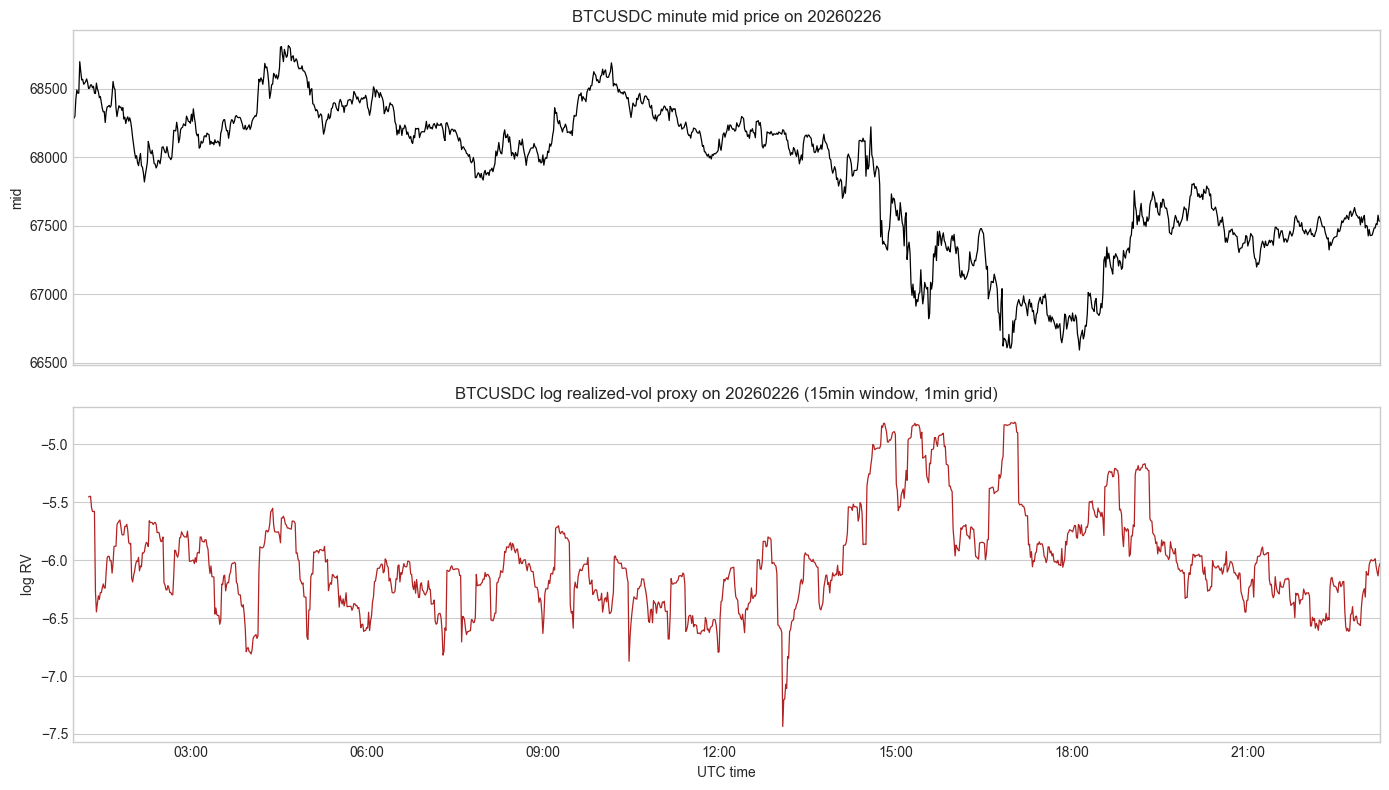

In [4]:
sample_day = days[0]
sample_proxy = daily[sample_day]["proxy"]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

sample_proxy["mid"].plot(ax=axes[0], color="black", lw=0.9)
axes[0].set_title(f"{symbol} minute mid price on {sample_day}")
axes[0].set_ylabel("mid")

sample_proxy["log_rv"].plot(ax=axes[1], color="firebrick", lw=0.9)
axes[1].set_title(f"{symbol} log realized-vol proxy on {sample_day} ({rv_window} window, {grid_freq} grid)")
axes[1].set_ylabel("log RV")
axes[1].set_xlabel("UTC time")

plt.tight_layout()


In [5]:
def estimate_scaling_exponents(log_vol: pd.Series, *, lags: list[int], q_grid: np.ndarray) -> dict:
    """Estimate zeta_q from log-log scaling and then estimate H from zeta_q ~ H q."""
    x = pd.to_numeric(log_vol, errors="coerce").dropna().to_numpy(dtype=float)
    if x.size <= max(lags) + 5:
        raise ValueError("Not enough observations for the requested lag grid")

    lag_array = np.asarray(lags, dtype=int)
    q_array = np.asarray(q_grid, dtype=float)

    q_rows = []
    zeta_values = []

    for q in q_array:
        lag_used = []
        moments = []
        for lag in lag_array:
            if lag >= x.size:
                continue
            diffs = np.abs(x[lag:] - x[:-lag]) ** q
            moment = float(np.nanmean(diffs))
            if np.isfinite(moment) and moment > 0:
                lag_used.append(float(lag))
                moments.append(moment)

        lag_used = np.asarray(lag_used, dtype=float)
        moments = np.asarray(moments, dtype=float)

        if lag_used.size < 2:
            zeta_values.append(np.nan)
            q_rows.append({"q": float(q), "zeta_q": np.nan, "lag_fit_intercept": np.nan, "lag_fit_r2": np.nan})
            continue

        lag_log = np.log(lag_used)
        moment_log = np.log(moments)
        slope, intercept = np.polyfit(lag_log, moment_log, 1)
        fitted = slope * lag_log + intercept
        ss_res = float(np.sum((moment_log - fitted) ** 2))
        ss_tot = float(np.sum((moment_log - moment_log.mean()) ** 2))
        r2 = np.nan if ss_tot == 0 else 1.0 - ss_res / ss_tot

        zeta_values.append(float(slope))
        q_rows.append({"q": float(q), "zeta_q": float(slope), "lag_fit_intercept": float(intercept), "lag_fit_r2": float(r2)})

    zeta_values = np.asarray(zeta_values, dtype=float)
    mask = np.isfinite(zeta_values)
    if mask.sum() < 2:
        raise ValueError("Not enough finite zeta_q values to estimate H")

    q_valid = q_array[mask]
    zeta_valid = zeta_values[mask]
    h_slope, h_intercept = np.polyfit(q_valid, zeta_valid, 1)
    fitted_zeta = h_slope * q_valid + h_intercept
    ss_res = float(np.sum((zeta_valid - fitted_zeta) ** 2))
    ss_tot = float(np.sum((zeta_valid - zeta_valid.mean()) ** 2))
    zeta_fit_r2 = np.nan if ss_tot == 0 else 1.0 - ss_res / ss_tot

    return {
        "H": float(h_slope),
        "H_intercept": float(h_intercept),
        "zeta_fit_r2": float(zeta_fit_r2),
        "zeta": pd.Series(zeta_values, index=q_array, name="zeta_q"),
        "q_table": pd.DataFrame(q_rows).set_index("q"),
    }


def rolling_h_estimates(log_vol: pd.Series, *, calibration_window: str, lags: list[int], q_grid: np.ndarray) -> pd.DataFrame:
    """Estimate H every minute on a causal rolling window."""
    x = pd.to_numeric(log_vol, errors="coerce").dropna()
    if x.empty:
        return pd.DataFrame(columns=["H", "H_intercept", "zeta_fit_r2", "n_obs"], index=pd.DatetimeIndex([], tz="UTC", name="ts"))

    step = pd.Timedelta(grid_freq)
    window_n = int(pd.Timedelta(calibration_window) / step)
    max_lag = int(max(lags))
    if window_n <= max_lag + 5:
        raise ValueError("calibration_window is too short for the requested lag grid")

    values = x.to_numpy(dtype=float)
    index = x.index
    rows = []

    for end in range(window_n, len(values) + 1):
        window = values[end - window_n : end]
        est = estimate_scaling_exponents(pd.Series(window), lags=lags, q_grid=q_grid)
        rows.append(
            {
                "ts": index[end - 1],
                "H": est["H"],
                "H_intercept": est["H_intercept"],
                "zeta_fit_r2": est["zeta_fit_r2"],
                "n_obs": int(window_n),
            }
        )

    out = pd.DataFrame(rows).set_index("ts")
    out.index = pd.to_datetime(out.index, utc=True)
    return out


In [6]:
full_h_rows = []
rolling_h_by_day = {}

for day in days:
    proxy = daily[day]["proxy"]
    full_est = estimate_scaling_exponents(proxy["log_rv"], lags=lag_minutes, q_grid=q_grid)
    rolling_est = rolling_h_estimates(proxy["log_rv"], calibration_window=calibration_window, lags=lag_minutes, q_grid=q_grid)

    full_h_rows.append(
        {
            "day": day,
            "H": full_est["H"],
            "H_intercept": full_est["H_intercept"],
            "zeta_fit_r2": full_est["zeta_fit_r2"],
            "n_obs": int(proxy["log_rv"].notna().sum()),
        }
    )
    rolling_h_by_day[day] = rolling_est

full_h_table = pd.DataFrame(full_h_rows).set_index("day")
full_h_table

sample_day = days[0]
sample_proxy = daily[sample_day]["proxy"]
scaling_table = []
log_delta = np.log(np.asarray(lag_minutes, dtype=float))

for q in np.asarray(q_grid, dtype=float):
    moments = []
    for lag in lag_minutes:
        log_vol = pd.to_numeric(sample_proxy["log_rv"], errors="coerce").dropna().to_numpy(dtype=float)
        if lag >= log_vol.size:
            continue
        moment = float(np.nanmean(np.abs(log_vol[lag:] - log_vol[:-lag]) ** q))
        moments.append(moment)
    scaling_table.append((q, np.log(np.asarray(moments, dtype=float))))

fig, ax = plt.subplots(figsize=(10, 6))
for q, log_m in scaling_table:
    ax.plot(log_delta[: len(log_m)], log_m, marker="o", ms=3, lw=1.0, label=f"q={q:g}")

ax.set_title(f"{symbol} scaling check on {sample_day}: log(m_q(Δ)) vs log(Δ)")
ax.set_xlabel("log(Δ in minutes)")
ax.set_ylabel("log m_q(Δ)")
ax.legend(title="Moment order", frameon=True)
plt.tight_layout()


,H,H_intercept,zeta_fit_r2,n_obs
day,,,,
20260226,0.312176,0.171554,0.983373,1320
20260227,0.313122,0.190446,0.974749,1320
20260228,0.394532,0.182608,0.989672,1320


In [7]:
rolling_h_summary = pd.DataFrame(
    [
        {
            "day": day,
            "H_mean": df["H"].mean(),
            "H_median": df["H"].median(),
            "H_std": df["H"].std(),
            "H_p10": df["H"].quantile(0.10),
            "H_p90": df["H"].quantile(0.90),
            "zeta_fit_r2_mean": df["zeta_fit_r2"].mean(),
        }
        for day, df in rolling_h_by_day.items()
        if not df.empty
    ]
).set_index("day")

rolling_h_summary


,H_mean,H_median,H_std,H_p10,H_p90,zeta_fit_r2_mean
day,,,,,,
20260226,0.299266,0.311127,0.088238,0.139553,0.393897,0.956246
20260227,0.321907,0.295278,0.075007,0.237087,0.437858,0.979139
20260228,0.390181,0.425581,0.093711,0.250706,0.489082,0.978360


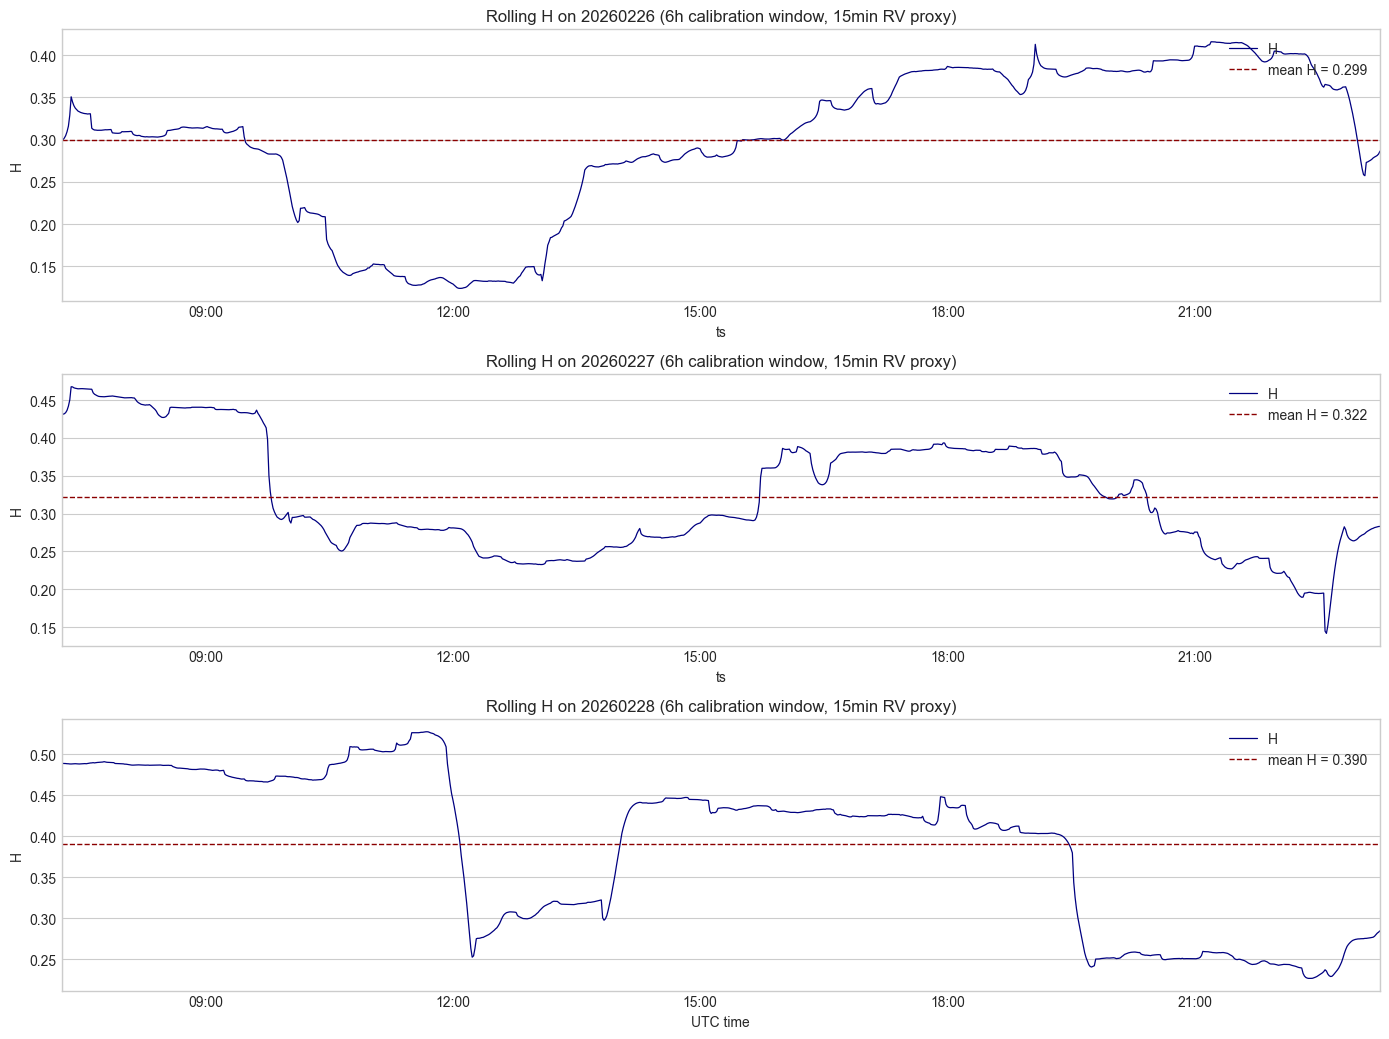

In [8]:
fig, axes = plt.subplots(len(rolling_h_by_day), 1, figsize=(14, 3.5 * max(1, len(rolling_h_by_day))), sharex=False)

if len(rolling_h_by_day) == 1:
    axes = [axes]

for ax, (day, df) in zip(axes, rolling_h_by_day.items()):
    if df.empty:
        ax.set_title(f"{day}: no rolling H estimates")
        continue
    df["H"].plot(ax=ax, color="navy", lw=0.9)
    ax.axhline(df["H"].mean(), color="darkred", ls="--", lw=1.0, label=f"mean H = {df['H'].mean():.3f}")
    ax.set_title(f"Rolling H on {day} ({calibration_window} calibration window, {rv_window} RV proxy)")
    ax.set_ylabel("H")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("UTC time")
plt.tight_layout()


In [9]:
rv_windows = ["15min", "30min", "1h"]
sensitivity_rows = []

for window in rv_windows:
    day_h = []
    for day in days:
        minute_mid = daily[day]["minute_mid"]
        proxy = build_roughness_proxy(minute_mid, rv_window=window)
        est = estimate_scaling_exponents(proxy["log_rv"], lags=lag_minutes, q_grid=q_grid)
        day_h.append(est["H"])

    day_h = np.asarray(day_h, dtype=float)
    sensitivity_rows.append(
        {
            "rv_window": window,
            "H_mean": float(np.nanmean(day_h)),
            "H_std": float(np.nanstd(day_h, ddof=1)) if day_h.size > 1 else np.nan,
            "H_min": float(np.nanmin(day_h)),
            "H_max": float(np.nanmax(day_h)),
        }
    )

sensitivity_table = pd.DataFrame(sensitivity_rows).set_index("rv_window")
sensitivity_table


,H_mean,H_std,H_min,H_max
rv_window,,,,
15min,0.339943,0.047278,0.312176,0.394532
30min,0.424108,0.056984,0.361658,0.473282
1h,0.467246,0.102150,0.367981,0.572056


## Reading the Output

Interpretation guide:

- `H` around `0.1` to `0.2` is the rough-volatility range reported in the paper.
- the rolling `H` plot is a diagnostic first pass, not the final structural estimate.
- if `H` stays stable across days and nearby proxy windows, the roughness signal is less likely to be an artifact of the proxy choice.
- if `H` moves a lot when the proxy window changes from `15min` to `1h`, the proxy is probably smoothing too aggressively.

Next checks that would make sense after this notebook:
- compare `1min` and `2min` return sampling
- compare rolling `15min`, `30min`, and `1h` volatility windows
- add the increment histogram / Gaussianity check from section 2.5 of the paper
